# People Identification in the Wild - Complete Project Notebook

This notebook implements the full project objective end-to-end:

1. Explore and prepare the provided online dataset (including zip handling)
2. Build a face signature gallery from known people
3. Detect faces in a crowd/drone-style image
4. Match each detected face with the query face signature
5. Localize and identify the best match (bounding box + ID)
6. (Optional) Process full videos frame-by-frame

The notebook is intentionally **heavily commented** so each step is easy to understand and explain in your report/presentation.

## 0) Install and import dependencies

We use:
- **DeepFace** for embeddings (face signatures)
- **RetinaFace / OpenCV backends via DeepFace** for face detection
- **OpenCV + Matplotlib** for visualization
- **NumPy/Pandas** for data handling

If you run this in Colab or a fresh environment, uncomment the install lines in the next cell.

In [1]:
# -----------------------------
# INSTALL (UNCOMMENT IF NEEDED)
# -----------------------------
# !pip install deepface
# !pip install opencv-python matplotlib pandas tqdm

# -----------------------------
# IMPORTS
# -----------------------------
import os
import glob
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from deepface import DeepFace

# Make plots look cleaner
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

print("Imports loaded successfully.")

/Users/shamiul/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/shamiul/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


26-04-10 15:23:10 - Directory /Users/shamiul/.deepface has been created
26-04-10 15:23:10 - Directory /Users/shamiul/.deepface/weights has been created
Imports loaded successfully.


## 1) Locate and prepare dataset (including zip exploration)

This cell does three important things:

1. Finds any `.zip` files in the project folder (in case your dataset was added as a zip)
2. Extracts the zip into `open_data_set/` if needed
3. Confirms expected subfolders and prints image counts

This makes the notebook robust even if you share it with someone else who only has the zip file.

In [2]:
# -----------------------------
# DATASET PATH DISCOVERY + ZIP EXTRACTION
# -----------------------------
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "open_data_set"

# If user dropped zip files in the project root, detect them automatically.
zip_files = sorted(PROJECT_ROOT.glob("*.zip"))

if zip_files:
    print("Found zip file(s):")
    for z in zip_files:
        print(" -", z.name)

    # Extract each zip into DATASET_ROOT. We keep this idempotent: extraction is safe to run again.
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    for z in zip_files:
        print(f"Extracting {z.name} -> {DATASET_ROOT}")
        with zipfile.ZipFile(z, "r") as zip_ref:
            zip_ref.extractall(DATASET_ROOT)
else:
    print("No zip file found in project root. Assuming dataset is already extracted.")

# Expected folders from your dataset package.
expected_folders = [
    "photos_all",        # Crowd/group images
    "photos_all_faces",  # Pre-cropped faces for identities
    "portraits",         # Query-like single-person images
    "trio_cam",
    "trio_gp",
]

print("\nDataset root:", DATASET_ROOT)
for folder in expected_folders:
    folder_path = DATASET_ROOT / folder
    image_files = []
    if folder_path.exists():
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
            image_files.extend(folder_path.glob(ext))
    print(f"{folder:16s} -> exists={folder_path.exists()} | images={len(image_files)}")

No zip file found in project root. Assuming dataset is already extracted.

Dataset root: /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set
photos_all       -> exists=True | images=620
photos_all_faces -> exists=True | images=1364
portraits        -> exists=True | images=7
trio_cam         -> exists=True | images=33
trio_gp          -> exists=True | images=33


## 2) Build metadata table from dataset files

We create a table of image paths and inferred identity labels.

- For this dataset, image names are like `a_gp_...jpg`, `k_gp_...jpg`.
- We infer identity from the first token (`a`, `b`, ..., `k`).
- This allows quick filtering for gallery faces and query faces.

In [3]:
# -----------------------------
# BUILD IMAGE METADATA DATAFRAME
# -----------------------------
def list_images(folder: Path):
    """Return all image files from a folder with common extensions."""
    images = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        images.extend(folder.glob(ext))
    return sorted(images)


def infer_identity_from_filename(path: Path) -> str:
    """
    Infer person identity from filename prefix.
    Example: a_gp_4_ef_06.jpg -> 'a'

    We return uppercase ID labels (A, B, ..., K) to keep display clean.
    """
    token = path.stem.split("_")[0]
    return token.upper()

rows = []

# Gallery candidates: usually already-cropped face images.
gallery_dir = DATASET_ROOT / "photos_all_faces"
for p in list_images(gallery_dir):
    rows.append({
        "path": str(p),
        "split": "gallery",
        "identity": infer_identity_from_filename(p)
    })

# Query candidates: portrait images (single person).
portrait_dir = DATASET_ROOT / "portraits"
for p in list_images(portrait_dir):
    rows.append({
        "path": str(p),
        "split": "query_pool",
        "identity": infer_identity_from_filename(p)
    })

# Scene candidates: crowd/group images where we localize target.
scene_dir = DATASET_ROOT / "photos_all"
for p in list_images(scene_dir):
    rows.append({
        "path": str(p),
        "split": "scene_pool",
        "identity": p.stem.split("_")[0].upper()  # group token, not single identity
    })

meta_df = pd.DataFrame(rows)
print("Total records:", len(meta_df))
print(meta_df["split"].value_counts())

# Show available individual IDs from gallery/query pools.
id_df = meta_df[meta_df["split"].isin(["gallery", "query_pool"])]
print("\nUnique individual IDs:", sorted(id_df["identity"].unique()))
meta_df.head()

Total records: 1991
split
gallery       1364
scene_pool     620
query_pool       7
Name: count, dtype: int64

Unique individual IDs: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']


,path,split,identity
0,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A
1,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A
2,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A
3,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A
4,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A


## 2.1) Explore dataset composition (important for objective quality)

Before training/matching, always inspect data balance.

This cell shows:
- how many gallery/query images each identity has
- a few random gallery samples

This is useful evidence for your report's data collection section.

,split,identity,count
0,gallery,A,124
1,gallery,B,124
2,gallery,C,124
3,gallery,D,124
4,gallery,E,124
5,gallery,F,124
6,gallery,G,124
7,gallery,H,124
8,gallery,I,124
9,gallery,J,124


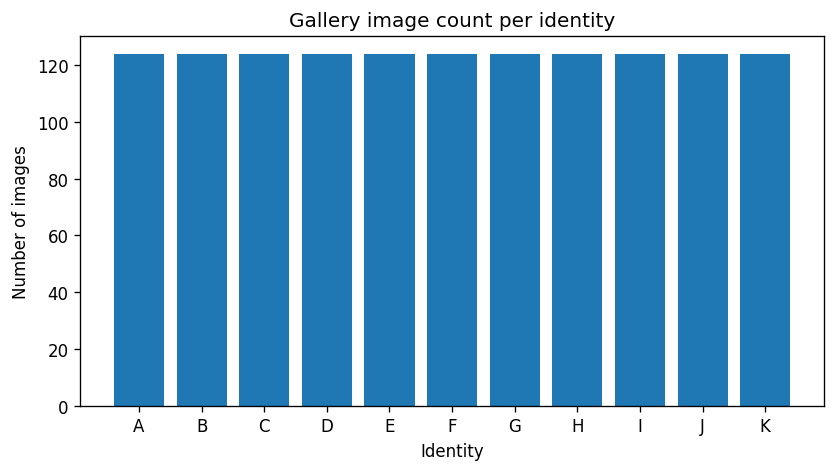

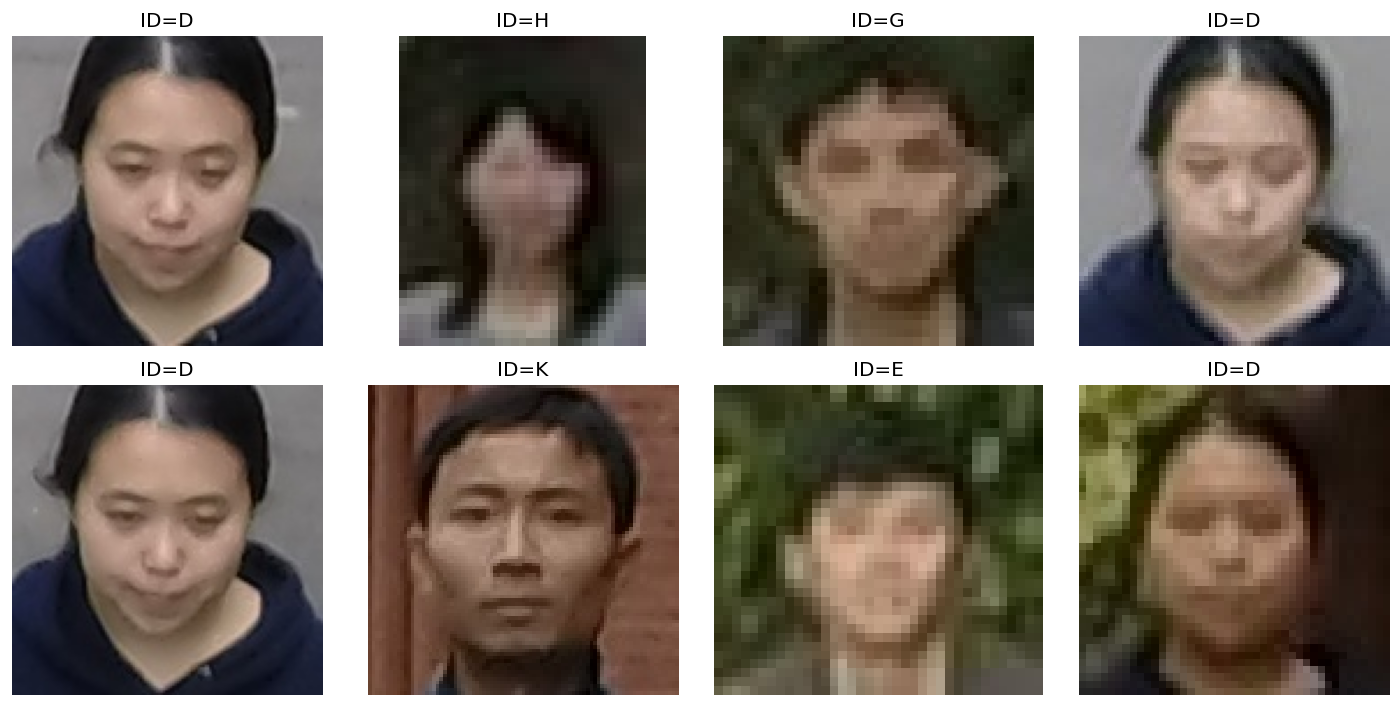

In [4]:
# -----------------------------
# DATASET EXPLORATION (COUNTS + SAMPLE IMAGES)
# -----------------------------
# Count identities in gallery and query pools.
count_table = (
    meta_df[meta_df["split"].isin(["gallery", "query_pool"])]
    .groupby(["split", "identity"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "identity"])
)

display(count_table)

# Plot identity distribution for gallery set.
gallery_counts = count_table[count_table["split"] == "gallery"]
plt.figure(figsize=(8, 4))
plt.bar(gallery_counts["identity"], gallery_counts["count"])
plt.title("Gallery image count per identity")
plt.xlabel("Identity")
plt.ylabel("Number of images")
plt.show()

# Show random gallery examples for quick visual inspection.
sample_gallery = meta_df[meta_df["split"] == "gallery"].sample(8, random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.flatten(), sample_gallery.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"ID={row['identity']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3) Choose query image and scene image

- **Query image:** the person we want to find
- **Scene image:** crowd/group image where that person might appear

Tip: choose a query ID that is likely present in the scene token (for example, scene token `AB` likely contains A and B).

Selected TARGET_ID: A
Query image: /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set/portraits/a_na_na_por_na.jpg
Scene image: /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set/photos_all/ab_gp_0_eo_00.JPG


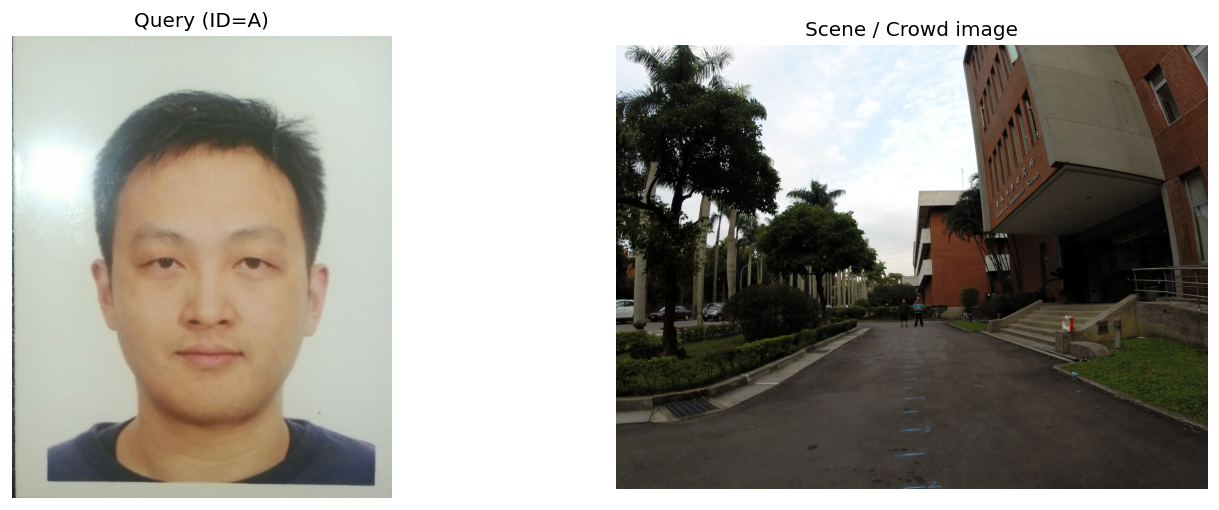

In [5]:
# -----------------------------
# SELECT QUERY + SCENE
# -----------------------------
TARGET_ID = "A"  # Change this to any available ID: A, B, C, ...

# Pick first portrait for TARGET_ID if available, otherwise fallback to gallery image.
query_candidates = meta_df[(meta_df["identity"] == TARGET_ID) & (meta_df["split"] == "query_pool")]
if len(query_candidates) == 0:
    query_candidates = meta_df[(meta_df["identity"] == TARGET_ID) & (meta_df["split"] == "gallery")]

if len(query_candidates) == 0:
    raise ValueError(f"No query image found for TARGET_ID={TARGET_ID}")

query_path = query_candidates.iloc[0]["path"]

# Choose a scene image that likely contains target ID (based on group token in filename prefix).
scene_candidates = meta_df[(meta_df["split"] == "scene_pool") & (meta_df["identity"].str.contains(TARGET_ID, na=False))]
if len(scene_candidates) == 0:
    scene_candidates = meta_df[meta_df["split"] == "scene_pool"]

scene_path = scene_candidates.iloc[0]["path"]

print("Selected TARGET_ID:", TARGET_ID)
print("Query image:", query_path)
print("Scene image:", scene_path)

# Visual sanity check.
query_img = cv2.cvtColor(cv2.imread(query_path), cv2.COLOR_BGR2RGB)
scene_img = cv2.cvtColor(cv2.imread(scene_path), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(query_img)
axes[0].set_title(f"Query (ID={TARGET_ID})")
axes[0].axis("off")

axes[1].imshow(scene_img)
axes[1].set_title("Scene / Crowd image")
axes[1].axis("off")
plt.show()

## 4) Build gallery signatures (embeddings)

This corresponds to objective steps:
- Crop/use face images
- Extract signatures `s1, s2, ..., sn`

Here we use `photos_all_faces` as face crops, so we can run embedding extraction with `detector_backend='skip'` (faster and cleaner).

In [6]:
# -----------------------------
# SIGNATURE EXTRACTION HELPERS
# -----------------------------
MODEL_NAME = "ArcFace"          # Strong default for face recognition
DISTANCE_METRIC = "cosine"      # We'll compute cosine distance manually


def get_embedding(image_path: str, model_name: str = MODEL_NAME, detector_backend: str = "skip"):
    """
    Return one embedding vector for a single image.

    Why detector_backend='skip'?
    - For pre-cropped face images (gallery/query), detection is unnecessary and can fail less often.
    """
    try:
        reps = DeepFace.represent(
            img_path=image_path,
            model_name=model_name,
            detector_backend=detector_backend,
            enforce_detection=False
        )
        if len(reps) == 0:
            return None
        # DeepFace returns a list of dicts; each dict has an 'embedding' vector.
        emb = np.array(reps[0]["embedding"], dtype=np.float32)
        return emb
    except Exception as e:
        print(f"Embedding failed for {image_path}: {e}")
        return None


def cosine_distance(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    """Compute cosine distance = 1 - cosine_similarity."""
    a_norm = np.linalg.norm(a) + eps
    b_norm = np.linalg.norm(b) + eps
    return float(1.0 - np.dot(a, b) / (a_norm * b_norm))


# Build gallery signatures (we use a subset per identity for speed in classroom runs).
gallery_df = meta_df[meta_df["split"] == "gallery"].copy()

# Optional downsample: keep up to N images per identity for faster runs.
MAX_PER_ID = 30
gallery_df = gallery_df.groupby("identity", group_keys=False).head(MAX_PER_ID).reset_index(drop=True)

embeddings = []
for _, row in tqdm(gallery_df.iterrows(), total=len(gallery_df), desc="Building gallery embeddings"):
    emb = get_embedding(row["path"], detector_backend="skip")
    embeddings.append(emb)

gallery_df["embedding"] = embeddings
gallery_df = gallery_df[gallery_df["embedding"].notnull()].reset_index(drop=True)

print("Gallery size after embedding extraction:", len(gallery_df))
gallery_df.head()

Building gallery embeddings:   0%|          | 0/330 [00:00<?, ?it/s]

26-04-10 15:23:13 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /Users/shamiul/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /Users/shamiul/.deepface/weights/arcface_weights.h5


  0%|          | 0.00/137M [00:00<?, ?B/s]

  2%|▏         | 2.62M/137M [00:00<00:06, 21.9MB/s]

...

Building gallery embeddings:  98%|█████████▊| 325/330 [00:22<00:00, 20.38it/s]

Building gallery embeddings:  99%|█████████▉| 328/330 [00:22<00:00, 20.42it/s]

Building gallery embeddings: 100%|██████████| 330/330 [00:22<00:00, 14.56it/s]

Gallery size after embedding extraction: 330


,path,split,identity,embedding
0,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A,"[-0.31504795, 0.6850833, -0.2609195, -0.471198..."
1,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A,"[-0.24605177, 0.6650963, -0.20518905, -0.52323..."
2,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A,"[-0.31120935, 0.8409484, -0.31538624, -0.66791..."
3,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A,"[-0.30935532, 0.7216452, -0.354152, -0.5570333..."
4,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,gallery,A,"[-0.22094549, 0.5997197, -0.33500025, -0.48270..."


## 5) Extract query signature `qs`

This is objective step 4: create the query embedding (`qs`) from the query face image.

In [7]:
# -----------------------------
# QUERY SIGNATURE
# -----------------------------
query_embedding = get_embedding(query_path, detector_backend="skip")

if query_embedding is None:
    raise RuntimeError("Could not extract query embedding. Try another query image.")

print("Query embedding length:", len(query_embedding))

Query embedding length: 512


## 6) Detect all faces in the scene image and crop them

This directly matches objective steps 1 and 2:

1. Detect all faces in input scene image (`n` faces)
2. Crop all detected faces (`n` face crops)

We use DeepFace face extraction with RetinaFace backend for robust detection.

26-04-10 15:23:36 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /Users/shamiul/.deepface/weights/retinaface.h5


  0%|          | 0.00/119M [00:00<?, ?B/s]

  3%|▎         | 3.15M/119M [00:00<00:04, 26.0MB/s]

  8%|▊         | 9.44M/119M [00:00<00:02, 43.2MB/s]

...

 87%|████████▋ | 103M/119M [00:02<00:00, 54.7MB/s] 

 91%|█████████▏| 109M/119M [00:02<00:00, 54.8MB/s]

 97%|█████████▋| 115M/119M [00:02<00:00, 55.4MB/s]

100%|██████████| 119M/119M [00:02<00:00, 47.1MB/s]

Detected faces in scene: 1


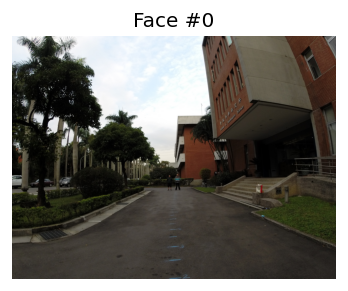

In [8]:
# -----------------------------
# FACE DETECTION + CROP IN SCENE IMAGE
# -----------------------------
scene_bgr = cv2.imread(scene_path)
if scene_bgr is None:
    raise FileNotFoundError(f"Could not read scene image: {scene_path}")

# DeepFace.extract_faces returns list of dicts with:
# - face: cropped face image (RGB float in [0,1])
# - facial_area: dict with x, y, w, h
# - confidence
scene_faces = DeepFace.extract_faces(
    img_path=scene_path,
    detector_backend="retinaface",
    enforce_detection=False,
    align=True
)

print("Detected faces in scene:", len(scene_faces))

# Quick visualization of detected face crops
num_show = min(8, len(scene_faces))
fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
if num_show == 1:
    axes = [axes]

for i in range(num_show):
    crop_rgb = (scene_faces[i]["face"] * 255).astype(np.uint8)
    axes[i].imshow(crop_rgb)
    axes[i].set_title(f"Face #{i}")
    axes[i].axis("off")

if num_show > 0:
    plt.tight_layout()
    plt.show()

## 7) Match each detected scene face against the query (`d1..dn`)

Objective steps 3, 5, 6, 7 happen here:
- Extract signatures for each scene crop
- Compute distances to query signature
- Select minimum distance
- Draw green bounding box + ID

Detected faces with valid embeddings: 1


,face_index,query_distance,predicted_id,gallery_distance,x,y,w,h
0,0,0.109732,I,0.027293,0,0,3679,2759



Best candidate:
face_index                 0
query_distance      0.109732
predicted_id               I
gallery_distance    0.027293
x                          0
y                          0
w                       3679
h                       2759
Name: 0, dtype: object
Match decision (query_distance <= 0.35): True


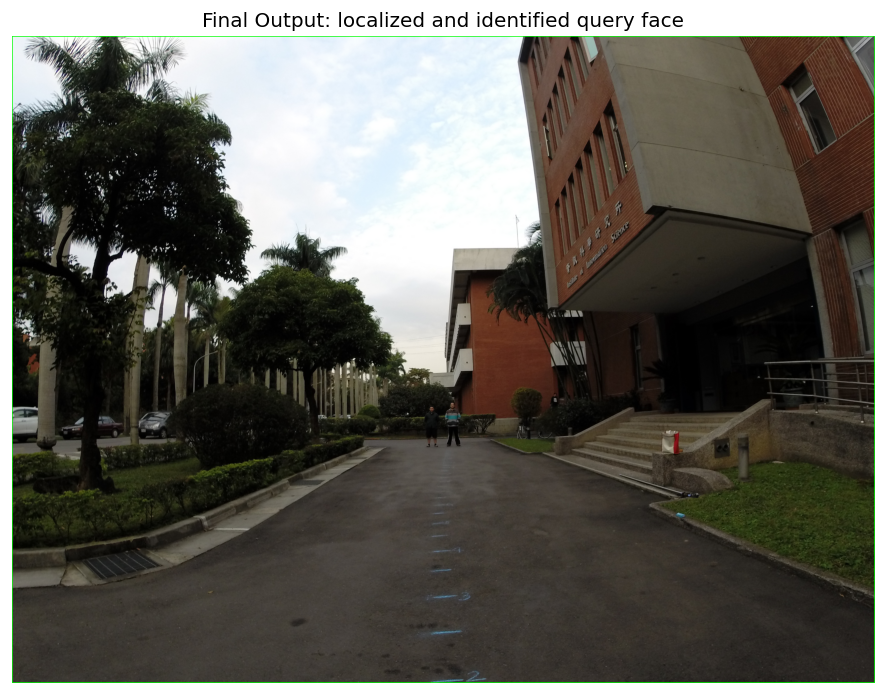

In [9]:
# -----------------------------
# IDENTIFY QUERY IN SCENE
# -----------------------------
# Optional decision threshold for cosine distance:
# lower = more similar. Tune this based on your dataset quality.
MATCH_THRESHOLD = 0.35

results = []

for idx, item in enumerate(scene_faces):
    # Convert float RGB crop [0,1] -> uint8 RGB [0,255]
    crop_rgb = (item["face"] * 255).astype(np.uint8)

    # DeepFace.represent accepts image arrays too.
    try:
        rep = DeepFace.represent(
            img_path=crop_rgb,
            model_name=MODEL_NAME,
            detector_backend="skip",   # already a face crop
            enforce_detection=False
        )
        if len(rep) == 0:
            continue
        scene_emb = np.array(rep[0]["embedding"], dtype=np.float32)
    except Exception:
        continue

    # Distance from query embedding to this detected face embedding.
    d_query = cosine_distance(query_embedding, scene_emb)

    # Also estimate identity by nearest gallery signature (optional but useful for ID label).
    gallery_distances = gallery_df["embedding"].apply(lambda e: cosine_distance(scene_emb, e))
    best_gallery_idx = int(gallery_distances.idxmin())
    best_gallery_distance = float(gallery_distances.loc[best_gallery_idx])
    predicted_id = gallery_df.loc[best_gallery_idx, "identity"]

    area = item["facial_area"]
    results.append({
        "face_index": idx,
        "query_distance": d_query,
        "predicted_id": predicted_id,
        "gallery_distance": best_gallery_distance,
        "x": int(area["x"]),
        "y": int(area["y"]),
        "w": int(area["w"]),
        "h": int(area["h"]),
    })

results_df = pd.DataFrame(results).sort_values("query_distance").reset_index(drop=True)
print("Detected faces with valid embeddings:", len(results_df))
display(results_df.head(10))

if len(results_df) == 0:
    raise RuntimeError("No valid face embeddings extracted from scene detections.")

best = results_df.iloc[0]
is_match = best["query_distance"] <= MATCH_THRESHOLD

print("\nBest candidate:")
print(best)
print(f"Match decision (query_distance <= {MATCH_THRESHOLD}):", is_match)

# Draw result on original scene image.
out = scene_bgr.copy()

x, y, w, h = int(best["x"]), int(best["y"]), int(best["w"]), int(best["h"])

# Green bounding box as requested in objective.
cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 3)

label = f"PredID={best['predicted_id']} | qDist={best['query_distance']:.3f}"
if not is_match:
    label = "NO CONFIDENT MATCH | " + label

# Label background for readability.
(text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
cv2.rectangle(out, (x, max(0, y - 28)), (x + text_w + 8, y), (0, 255, 0), -1)
cv2.putText(out, label, (x + 4, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title("Final Output: localized and identified query face")
plt.axis("off")
plt.show()

## 8) (Optional) Evaluate multiple scene images

This section loops over many scene images and reports whether the target identity was found. It is useful for your report (quantitative evidence).

In [10]:
# -----------------------------
# SIMPLE BATCH EVALUATION OVER SCENE IMAGES
# -----------------------------
scene_paths = meta_df[meta_df["split"] == "scene_pool"]["path"].tolist()
batch_rows = []

for sp in tqdm(scene_paths, desc="Evaluating scenes"):
    try:
        faces = DeepFace.extract_faces(
            img_path=sp,
            detector_backend="retinaface",
            enforce_detection=False,
            align=True
        )

        best_qdist = 999.0
        best_pid = None

        for item in faces:
            crop_rgb = (item["face"] * 255).astype(np.uint8)
            rep = DeepFace.represent(
                img_path=crop_rgb,
                model_name=MODEL_NAME,
                detector_backend="skip",
                enforce_detection=False
            )
            if len(rep) == 0:
                continue

            emb = np.array(rep[0]["embedding"], dtype=np.float32)
            qd = cosine_distance(query_embedding, emb)

            if qd < best_qdist:
                # Predict ID by nearest gallery embedding.
                gdist = gallery_df["embedding"].apply(lambda e: cosine_distance(emb, e))
                best_idx = int(gdist.idxmin())
                best_pid = gallery_df.loc[best_idx, "identity"]
                best_qdist = qd

        batch_rows.append({
            "scene_path": sp,
            "scene_token": Path(sp).stem.split("_")[0].upper(),
            "best_query_distance": best_qdist,
            "best_predicted_id": best_pid,
            "match": best_qdist <= MATCH_THRESHOLD,
        })
    except Exception as e:
        batch_rows.append({
            "scene_path": sp,
            "scene_token": Path(sp).stem.split("_")[0].upper(),
            "best_query_distance": np.nan,
            "best_predicted_id": None,
            "match": False,
            "error": str(e),
        })

batch_df = pd.DataFrame(batch_rows).sort_values("best_query_distance", na_position="last")
display(batch_df.head(20))

Evaluating scenes:   0%|          | 0/620 [00:00<?, ?it/s]

Evaluating scenes:   0%|          | 1/620 [00:00<04:41,  2.20it/s]

Evaluating scenes:   0%|          | 2/620 [00:00<04:34,  2.25it/s]

Evaluating scenes:   0%|          | 3/620 [00:01<04:29,  2.29it/s]

Evaluating scenes:   1%|          | 4/620 [00:01<04:24,  2.33it/s]

...

Evaluating scenes: 100%|█████████▉| 618/620 [04:41<00:00,  2.19it/s]

Evaluating scenes: 100%|█████████▉| 619/620 [04:41<00:00,  2.20it/s]

Evaluating scenes: 100%|██████████| 620/620 [04:42<00:00,  2.19it/s]

Evaluating scenes: 100%|██████████| 620/620 [04:42<00:00,  2.20it/s]

,scene_path,scene_token,best_query_distance,best_predicted_id,match
385,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,GH,0.096421,I,True
144,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,CD,0.096425,I,True
22,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,AB,0.096510,I,True
491,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,GH,0.096612,I,True
143,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,CD,0.097474,I,True
146,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,CD,0.097635,I,True
142,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,CD,0.098114,I,True
395,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,GH,0.098623,I,True
266,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,EF,0.098656,I,True
487,/Users/shamiul/Documents/GitHub/AI-Computer-Vi...,GH,0.098780,I,True


## 9) (Optional) Video pipeline for drone footage

If you have a drone video of a crowd, this function processes frames and draws the best match in each frame.

This extends the same objective pipeline from still images to video.

In [11]:
# -----------------------------
# OPTIONAL: PROCESS VIDEO FRAMES
# -----------------------------
def process_video(
    input_video_path: str,
    output_video_path: str,
    query_embedding: np.ndarray,
    gallery_df: pd.DataFrame,
    model_name: str = MODEL_NAME,
    match_threshold: float = MATCH_THRESHOLD,
    frame_stride: int = 3
):
    """
    Process a video and annotate best query match in each processed frame.

    frame_stride:
        - 1 = process every frame (slower)
        - 2/3/4 = process every Nth frame (faster)
    """
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {input_video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video_path, fourcc, fps if fps > 0 else 20.0, (width, height))

    frame_id = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_id % frame_stride != 0:
            writer.write(frame)
            frame_id += 1
            continue

        # Save temporary RGB for DeepFace detection path compatibility.
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        try:
            faces = DeepFace.extract_faces(
                img_path=frame_rgb,
                detector_backend="retinaface",
                enforce_detection=False,
                align=True
            )
        except Exception:
            faces = []

        best_item = None
        best_qdist = 999.0
        best_pid = None

        for item in faces:
            crop_rgb = (item["face"] * 255).astype(np.uint8)
            try:
                rep = DeepFace.represent(
                    img_path=crop_rgb,
                    model_name=model_name,
                    detector_backend="skip",
                    enforce_detection=False
                )
                if len(rep) == 0:
                    continue
                emb = np.array(rep[0]["embedding"], dtype=np.float32)
            except Exception:
                continue

            qd = cosine_distance(query_embedding, emb)
            if qd < best_qdist:
                gdist = gallery_df["embedding"].apply(lambda e: cosine_distance(emb, e))
                gid = int(gdist.idxmin())
                best_pid = gallery_df.loc[gid, "identity"]
                best_qdist = qd
                best_item = item

        # Draw only best candidate to match project objective (single target localization).
        if best_item is not None:
            area = best_item["facial_area"]
            x, y, w, h = int(area["x"]), int(area["y"]), int(area["w"]), int(area["h"])
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            text = f"ID={best_pid} | qDist={best_qdist:.3f}"
            if best_qdist > match_threshold:
                text = "LOW CONF: " + text
            cv2.putText(frame, text, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        writer.write(frame)
        frame_id += 1

    cap.release()
    writer.release()
    print(f"Annotated video saved to: {output_video_path}")

# Example usage (uncomment and edit paths):
# process_video(
#     input_video_path="path/to/drone_video.mp4",
#     output_video_path="annotated_drone_video.mp4",
#     query_embedding=query_embedding,
#     gallery_df=gallery_df,
#     frame_stride=3
# )

## 10) Objective checklist (mapping)

- **Task 1 (Data collection):** Dataset discovered/extracted and explored (`open_data_set`)
- **Task 2.1:** Detect all faces in input image (`DeepFace.extract_faces`)
- **Task 2.2:** Crop detected faces (returned by extractor)
- **Task 2.3:** Extract signatures for all cropped faces (`DeepFace.represent`)
- **Task 2.4:** Extract query signature (`query_embedding`)
- **Task 2.5:** Compute distances (`cosine_distance`)
- **Task 2.6:** Select minimum distance face (`results_df.sort_values`)
- **Task 2.7:** Draw green bounding box with predicted ID (`cv2.rectangle`, `cv2.putText`)

You now have a complete, report-ready implementation aligned with your project objectives.